Importing all the needed libraries

In [887]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay , classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import torch
from torch import nn
from torch.nn import Sequential

Reading the train.csv file

In [888]:
df = pd.read_csv('train.csv')

Exploring the columns and rows in the CSV file

In [889]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Checking NaN values precentage in each column

In [890]:
df.isna().sum() / df.shape[0]

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

Dropping the Cabin column because it has too many NaN values and it isn't benefecial

In [891]:
df = df.drop('Cabin',axis=1)

In [892]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [893]:
mean_of_age = df['Age'].mean()

Filling the NaN values in the Age column by the mean of ages

In [894]:
df['Age'].fillna(mean_of_age,inplace=True)

C:\Users\Hp\AppData\Local\Temp\ipykernel_19640\4029026254.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(mean_of_age,inplace=True)


The rest of the NaN are little so i get rid of them by dropping all the remaining NaN values

In [895]:
df.dropna(inplace=True)

In [896]:
df.isna().sum() / df.shape[0]

PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
dtype: float64

In [897]:
df.shape

(889, 11)

In [898]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

Checking the distribution of each column and the relations between columns and each other (Important for modeling phase)

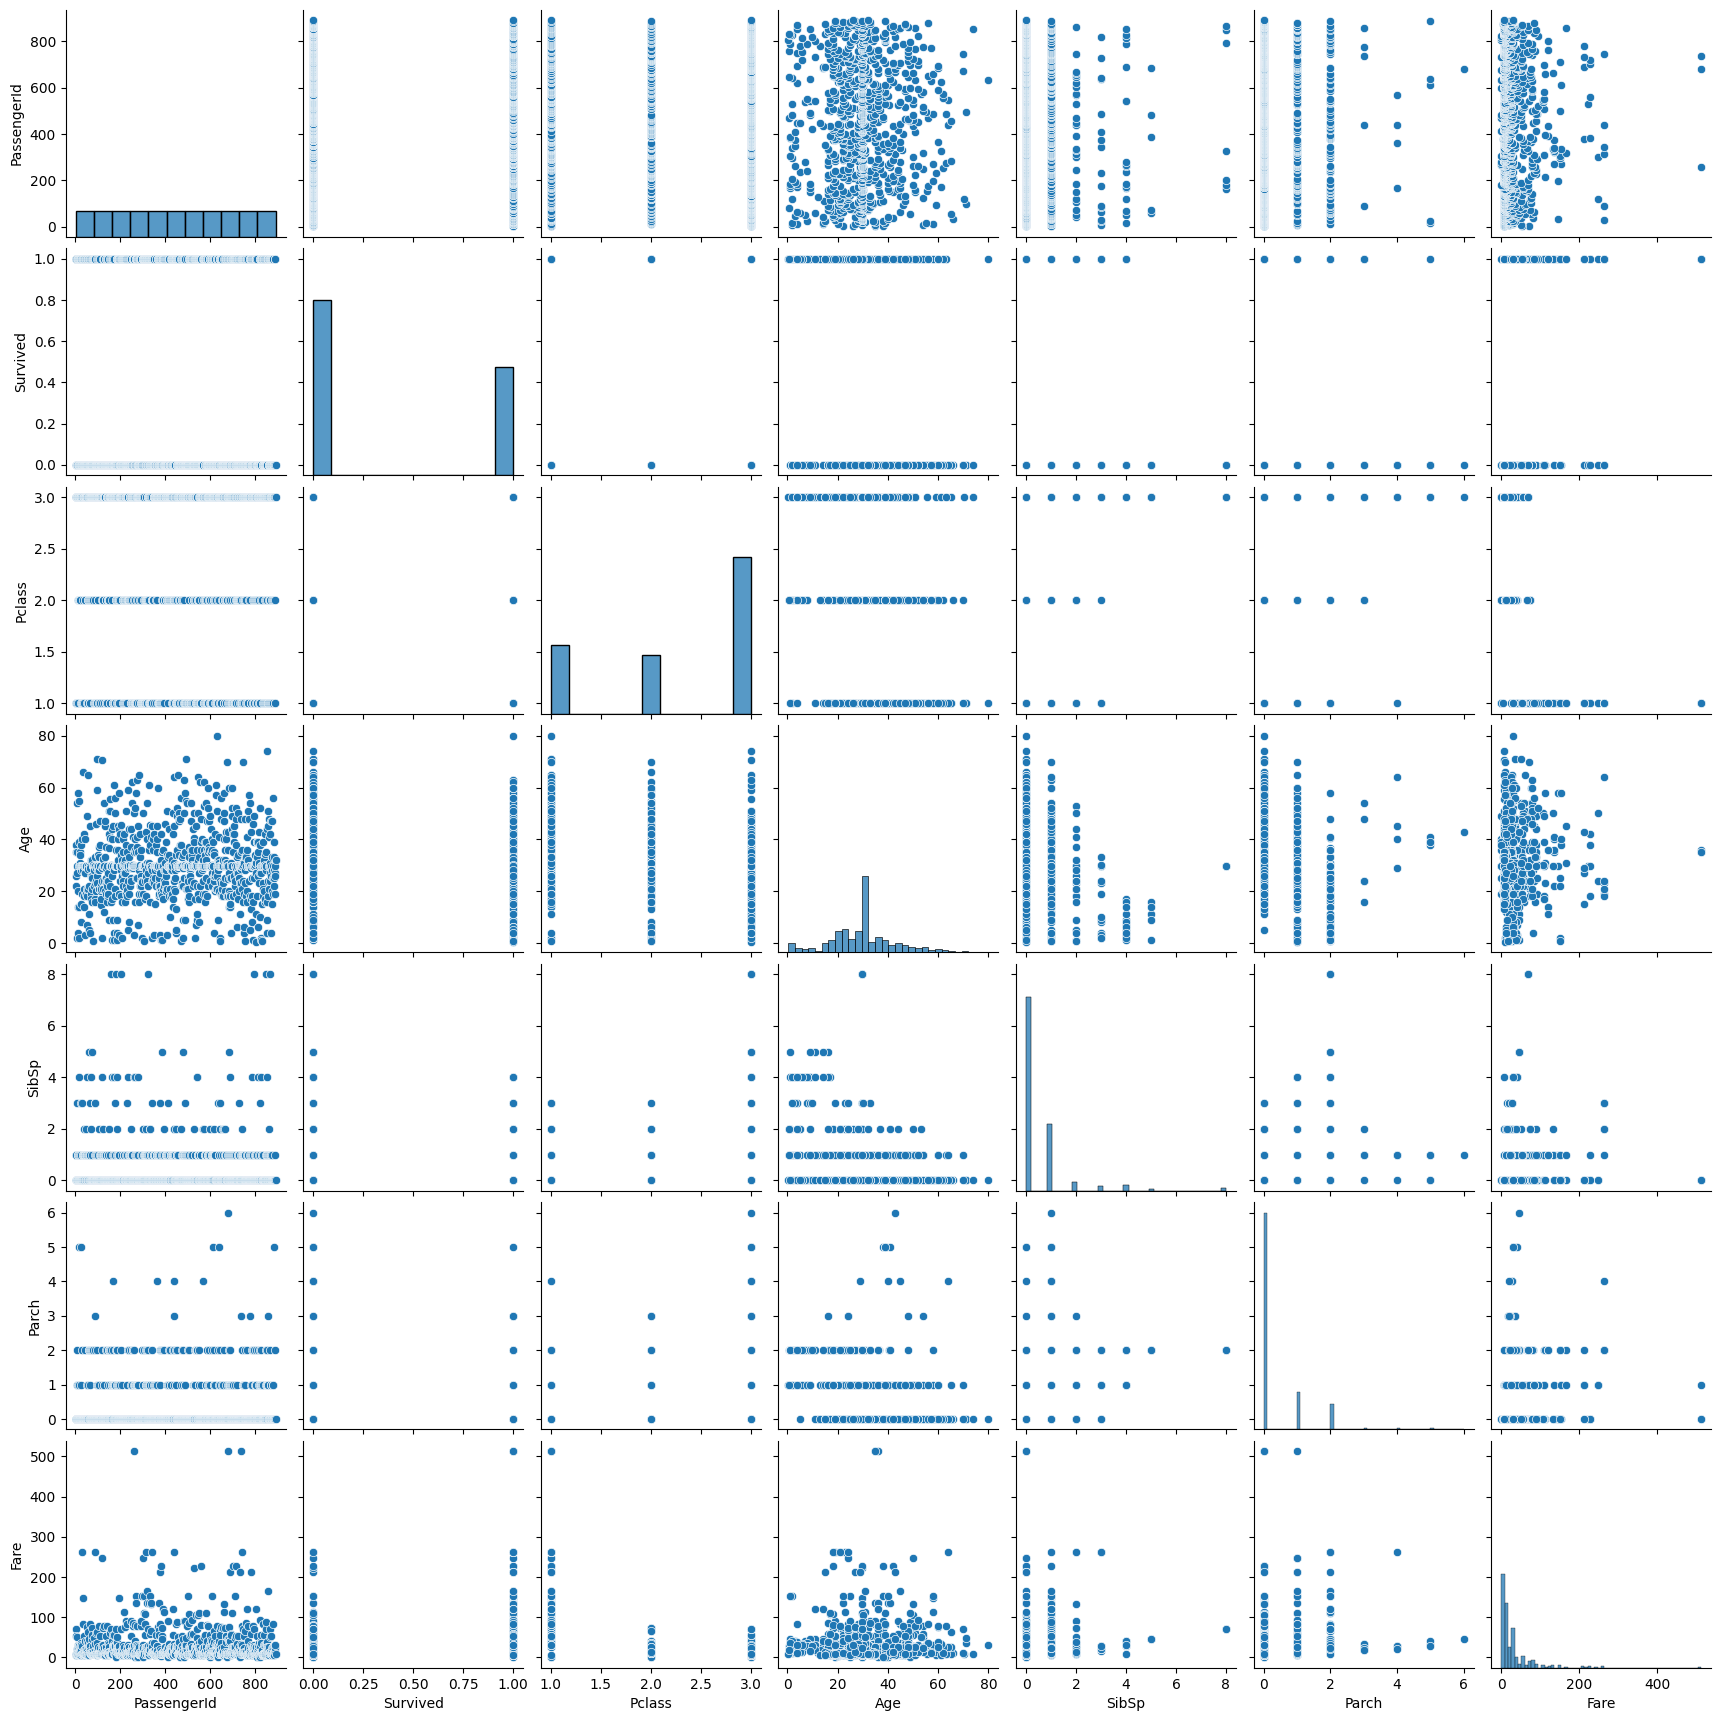

In [899]:
sns.pairplot(df)

Modeling phase

preprocessing Columns for the model 

In [900]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


Using oneHotEncoder for the categorical values

In [901]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = encoder.fit_transform(df[['Sex', 'Embarked']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['Sex', 'Embarked']))

In [902]:
df = df.drop(['Sex', 'Embarked'], axis=1)


In [903]:
df = pd.concat([df.reset_index(drop=True), encoded_df], axis=1)

In [904]:
df

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.000000,1,0,A/5 21171,7.2500,0.0,1.0,0.0,0.0,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.000000,1,0,PC 17599,71.2833,1.0,0.0,1.0,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",26.000000,0,0,STON/O2. 3101282,7.9250,1.0,0.0,0.0,0.0,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.000000,1,0,113803,53.1000,1.0,0.0,0.0,0.0,1.0
4,5,0,3,"Allen, Mr. William Henry",35.000000,0,0,373450,8.0500,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
884,887,0,2,"Montvila, Rev. Juozas",27.000000,0,0,211536,13.0000,0.0,1.0,0.0,0.0,1.0
885,888,1,1,"Graham, Miss. Margaret Edith",19.000000,0,0,112053,30.0000,1.0,0.0,0.0,0.0,1.0
886,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",29.699118,1,2,W./C. 6607,23.4500,1.0,0.0,0.0,0.0,1.0
887,890,1,1,"Behr, Mr. Karl Howell",26.000000,0,0,111369,30.0000,0.0,1.0,1.0,0.0,0.0


In [905]:
df = df.drop(['Name','PassengerId','Ticket'],axis=1)

In [906]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,0.0,1.0,0.0,0.0,1.0
1,1,1,38.0,1,0,71.2833,1.0,0.0,1.0,0.0,0.0
2,1,3,26.0,0,0,7.9250,1.0,0.0,0.0,0.0,1.0
3,1,1,35.0,1,0,53.1000,1.0,0.0,0.0,0.0,1.0
4,0,3,35.0,0,0,8.0500,0.0,1.0,0.0,0.0,1.0


In [907]:
df.shape

(889, 11)

Using StandardScaler for numerical values

In [908]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[['Age', 'Fare']])
scaled_df = pd.DataFrame(scaled_data, columns=['Age_scaled', 'Fare_scaled'])
df_scaled = pd.concat([df, scaled_df], axis=1)
df_scaled.drop(['Age','Fare'],axis=1,inplace=True)

In [909]:
df_scaled

,Survived,Pclass,SibSp,Parch,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Age_scaled,Fare_scaled
0,0,3,1,0,0.0,1.0,0.0,0.0,1.0,-0.590495,-0.500240
1,1,1,1,0,1.0,0.0,1.0,0.0,0.0,0.643971,0.788947
2,1,3,0,0,1.0,0.0,0.0,0.0,1.0,-0.281878,-0.486650
3,1,1,1,0,1.0,0.0,0.0,0.0,1.0,0.412509,0.422861
4,0,3,0,0,0.0,1.0,0.0,0.0,1.0,0.412509,-0.484133
...,...,...,...,...,...,...,...,...,...,...,...
884,0,2,0,0,0.0,1.0,0.0,0.0,1.0,-0.204724,-0.384475
885,1,1,0,0,1.0,0.0,0.0,0.0,1.0,-0.821957,-0.042213
886,0,3,1,2,1.0,0.0,0.0,0.0,1.0,0.003524,-0.174084
887,1,1,0,0,0.0,1.0,1.0,0.0,0.0,-0.281878,-0.042213


In [910]:
y = df_scaled['Survived'].values

In [911]:
X = df_scaled.drop('Survived',axis=1)

In [912]:
X_columns = X.columns
X_columns

Index(['Pclass', 'SibSp', 'Parch', 'Sex_female', 'Sex_male', 'Embarked_C',
       'Embarked_Q', 'Embarked_S', 'Age_scaled', 'Fare_scaled'],
      dtype='object')

In [913]:
X = X.values

splitting the data to test and validate the models on unseen data (X_test , y_test) after training (X_train,y_train)

In [914]:
X_train , X_test , y_train , y_test = train_test_split(X,y,shuffle=True,test_size=0.1)

setting up the model

In [915]:
model = LogisticRegression(random_state=0)
model.fit(X,y)

LogisticRegression(random_state=0)

In [916]:
y_pred = model.predict(X_test)
cm_LR = confusion_matrix(y_pred,y_test)

results:

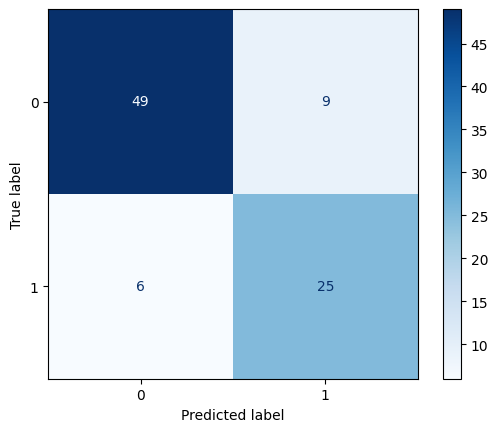

In [917]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_LR, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.show()
report_of_logistic_regression = classification_report(y_test,y_pred)

In [918]:
print(report_of_logistic_regression)

              precision    recall  f1-score   support

           0       0.84      0.89      0.87        55
           1       0.81      0.74      0.77        34

    accuracy                           0.83        89
   macro avg       0.83      0.81      0.82        89
weighted avg       0.83      0.83      0.83        89



Logistic Regression did a pretty good result but lets try other options

Using Decision Tree classifier and fitting it to the training data

In [919]:
model = DecisionTreeClassifier(random_state=0)
model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=0)

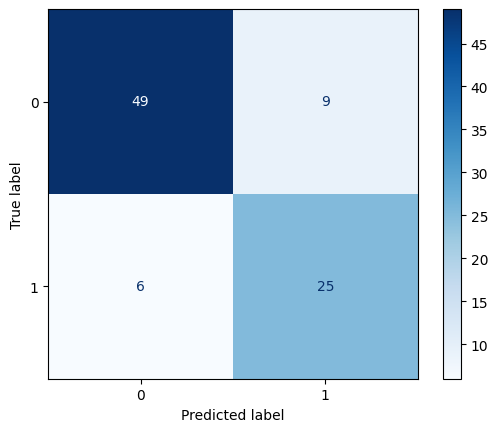

In [920]:
y_pred = model.predict(X_test)
cm_DT = confusion_matrix(y_true=y_test,y_pred=y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_LR, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.show()
report_of_Decision_Tree = classification_report(y_test,y_pred)

In [921]:
print(report_of_Decision_Tree)

              precision    recall  f1-score   support

           0       0.87      0.84      0.85        55
           1       0.75      0.79      0.77        34

    accuracy                           0.82        89
   macro avg       0.81      0.82      0.81        89
weighted avg       0.82      0.82      0.82        89



Trying Random Forest now

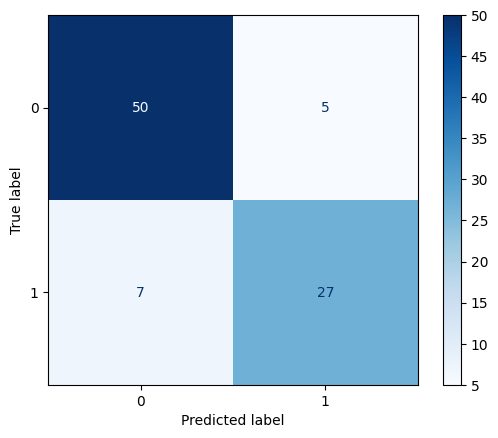

              precision    recall  f1-score   support

           0       0.88      0.91      0.89        55
           1       0.84      0.79      0.82        34

    accuracy                           0.87        89
   macro avg       0.86      0.85      0.86        89
weighted avg       0.86      0.87      0.86        89



In [922]:
RF_model = RandomForestClassifier(random_state=1)
RF_model.fit(X_train,y_train)
y_pred = RF_model.predict(X_test)
cm_RF = confusion_matrix(y_true=y_test,y_pred=y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_RF, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.show()
report_of_RF = classification_report(y_true=y_test,y_pred=y_pred)
print(report_of_RF)

for Neural Networks (without ReLU activation function)

In [923]:
X_train = torch.tensor(X_train,dtype=torch.float32)
X_test = torch.tensor(X_test,dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)


model = nn.Sequential(
    nn.Linear(10, 64),
    nn.Linear(64, 1),
)

# Loss, Optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Training Loop
EPOCHS = 10000
loss_list = []

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()

    y_pred = model(X_train)  
    loss = loss_fn(y_pred.squeeze(), y_train.float())
    
    loss.backward()
    optimizer.step()

    loss_list.append(loss.item())
    if epoch % 1000 == 0 or epoch == EPOCHS - 1:
        print(f'Loss: {loss.item():.4f} - Epoch: {epoch}')

Loss: 0.9318 - Epoch: 0
Loss: 0.4617 - Epoch: 1000
Loss: 0.4508 - Epoch: 2000
Loss: 0.4475 - Epoch: 3000
Loss: 0.4465 - Epoch: 4000
Loss: 0.4462 - Epoch: 5000
Loss: 0.4461 - Epoch: 6000
Loss: 0.4461 - Epoch: 7000
Loss: 0.4460 - Epoch: 8000
Loss: 0.4460 - Epoch: 9000
Loss: 0.4460 - Epoch: 9999


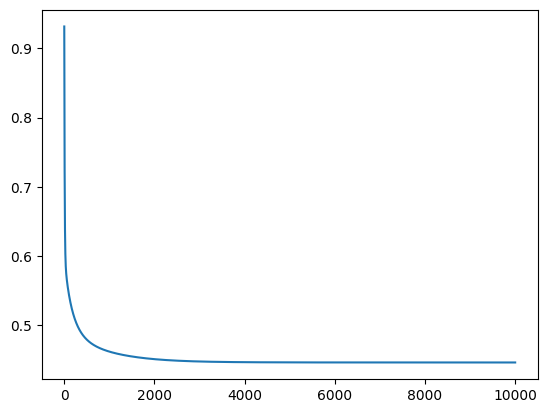

In [924]:
plt.plot(loss_list)

In [925]:
for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()

    y_pred = model(X_train)  
    loss = loss_fn(y_pred.squeeze(), y_train.float())
    
    loss.backward()
    optimizer.step()

    loss_list.append(loss.item())
    if epoch % 100 == 0 or epoch == EPOCHS - 1:
        print(f'Loss: {loss.item():.4f} - Epoch: {epoch}')

Loss: 0.4460 - Epoch: 0
Loss: 0.4460 - Epoch: 100
Loss: 0.4460 - Epoch: 200
Loss: 0.4460 - Epoch: 300
Loss: 0.4460 - Epoch: 400
Loss: 0.4460 - Epoch: 500
Loss: 0.4460 - Epoch: 600
Loss: 0.4460 - Epoch: 700
Loss: 0.4460 - Epoch: 800
Loss: 0.4460 - Epoch: 900
Loss: 0.4460 - Epoch: 1000
Loss: 0.4460 - Epoch: 1100
Loss: 0.4460 - Epoch: 1200
Loss: 0.4460 - Epoch: 1300
Loss: 0.4460 - Epoch: 1400
Loss: 0.4460 - Epoch: 1500
Loss: 0.4460 - Epoch: 1600
Loss: 0.4460 - Epoch: 1700
Loss: 0.4460 - Epoch: 1800
Loss: 0.4460 - Epoch: 1900
Loss: 0.4460 - Epoch: 2000
Loss: 0.4460 - Epoch: 2100
Loss: 0.4460 - Epoch: 2200
Loss: 0.4460 - Epoch: 2300
Loss: 0.4460 - Epoch: 2400
Loss: 0.4460 - Epoch: 2500
Loss: 0.4460 - Epoch: 2600
Loss: 0.4460 - Epoch: 2700
Loss: 0.4460 - Epoch: 2800
Loss: 0.4460 - Epoch: 2900
Loss: 0.4460 - Epoch: 3000
Loss: 0.4460 - Epoch: 3100
Loss: 0.4460 - Epoch: 3200
Loss: 0.4460 - Epoch: 3300
Loss: 0.4460 - Epoch: 3400
Loss: 0.4460 - Epoch: 3500
Loss: 0.4460 - Epoch: 3600
Loss: 0.4460 

In [926]:
with torch.no_grad():
    model.eval()
    y_pred = model(X_test)
    y_pred = torch.sigmoid(y_pred)

y_pred_classes = (y_pred > 0.5).float()
def accuracy_score(y_true, y_pred):
    if y_pred.max() > 1 or y_pred.min() < 0:
        y_pred = torch.sigmoid(y_pred)

    y_pred_labels = (y_pred > 0.5).float()

    y_true = y_true.view(-1)
    y_pred_labels = y_pred_labels.view(-1)

    correct = (y_pred_labels == y_true).float().sum()
    total = y_true.shape[0]

    return correct / total

accuracy_score(y_test,y_pred)

tensor(0.8315)

We can conclude that the best model was the RandomForest model

Now with the predictions for the test.csv data 

In [927]:
test_data = pd.read_csv('test.csv')

In [928]:
test_data

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [929]:
test_data.isna().sum() / test_data.shape[0]

PassengerId    0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.205742
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.002392
Cabin          0.782297
Embarked       0.000000
dtype: float64

In [939]:
test_data.drop(['Cabin','Name'],axis=1,inplace=True)
test_data['Age'].fillna(mean_of_age,inplace=True)
test_data['Fare'].fillna(test_data['Fare'].mean(),inplace=True)

KeyError: "['Cabin', 'Name'] not found in axis"

In [ ]:
encoded = encoder.transform(test_data[['Sex', 'Embarked']])
encoded_test_data = pd.DataFrame(encoded,
                                 columns=encoder.get_feature_names_out(['Sex', 'Embarked']),
                                 index=test_data.index)

scaled_data = scaler.transform(test_data[['Age', 'Fare']])
scaled_test_data = pd.DataFrame(scaled_data,
                                columns=['Age_scaled', 'Fare_scaled'],
                                index=test_data.index)

# Combine all
test_data_preprocessed = pd.concat([scaled_test_data, encoded_test_data], axis=1)
test_data_preprocessed = pd.concat([test_data_preprocessed, test_data[['Pclass', 'SibSp', 'Parch']]], axis=1)

In [940]:
test_data_preprocessed

,Pclass,SibSp,Parch,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Age_scaled,Fare_scaled
0,3,0,0,0.0,1.0,0.0,1.0,0.0,0.373932,-0.488579
1,3,1,0,1.0,0.0,0.0,0.0,1.0,1.338358,-0.505273
2,2,0,0,0.0,1.0,0.0,1.0,0.0,2.495670,-0.451165
3,3,0,0,0.0,1.0,0.0,0.0,1.0,-0.204724,-0.471802
4,3,1,1,1.0,0.0,0.0,0.0,1.0,-0.590495,-0.398819
...,...,...,...,...,...,...,...,...,...,...
413,3,0,0,0.0,1.0,0.0,0.0,1.0,0.047770,-0.484133
414,1,0,0,1.0,0.0,1.0,0.0,0.0,0.721125,1.546286
415,3,0,0,0.0,1.0,0.0,0.0,1.0,0.682548,-0.500240
416,3,0,0,0.0,1.0,0.0,0.0,1.0,0.047770,-0.484133


In [941]:
X = test_data_preprocessed.values

In [942]:
y_pred = RF_model.predict(X)

In [943]:
(y_pred == 0).sum()

np.int64(277)

In [944]:
test_data_preprocessed = test_data_preprocessed[X_columns]
test_data_preprocessed

,Pclass,SibSp,Parch,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Age_scaled,Fare_scaled
0,3,0,0,0.0,1.0,0.0,1.0,0.0,0.373932,-0.488579
1,3,1,0,1.0,0.0,0.0,0.0,1.0,1.338358,-0.505273
2,2,0,0,0.0,1.0,0.0,1.0,0.0,2.495670,-0.451165
3,3,0,0,0.0,1.0,0.0,0.0,1.0,-0.204724,-0.471802
4,3,1,1,1.0,0.0,0.0,0.0,1.0,-0.590495,-0.398819
...,...,...,...,...,...,...,...,...,...,...
413,3,0,0,0.0,1.0,0.0,0.0,1.0,0.047770,-0.484133
414,1,0,0,1.0,0.0,1.0,0.0,0.0,0.721125,1.546286
415,3,0,0,0.0,1.0,0.0,0.0,1.0,0.682548,-0.500240
416,3,0,0,0.0,1.0,0.0,0.0,1.0,0.047770,-0.484133


In [945]:
pred_series = pd.Series(y_pred, name='Survived')
submission = pd.concat([test_data['PassengerId'], pred_series], axis=1)

In [946]:
submission.to_csv('submission',index=False)